In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts
from sklearn import feature_selection
import SaveMol_GetDescriptors as smg
import pandas as pd
import numpy as np
import utils
import random
import xgboost as xgb
import pickle
import graph

In [3]:
data_train0 = pd.read_excel("train_data/train_descriptor_class_new.xlsx")
data_train0

,num,smiles,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,...,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF,Concentration,Temperature,Time(h),class
0,0,CCCCN1C=C[N+](C)=C1,7.846042,7.846042,0.019689,-3.810634,39.000000,139.222,56,0,...,2.627785,0.006569,0.988805,0.618340,0.168409,0.554439,0.359144,30,168.0,1
1,1,CCCCN1C=C[N+](C)=C1,7.846042,7.846042,0.019689,-3.810634,39.000000,139.222,56,0,...,2.627785,0.006569,0.988805,0.618340,0.168409,0.554439,3.591438,30,168.0,0
2,2,CCCCN1C=C[N+](C)=C1,7.846042,7.846042,0.019689,-3.810634,39.000000,139.222,56,0,...,2.627785,0.006569,0.988805,0.618340,0.168409,0.554439,8.978595,30,168.0,0
3,3,CCCCN1C=C[N+](C)=C1C,7.996042,7.996042,0.165522,-3.973134,40.545455,153.249,62,0,...,2.525381,0.003558,0.957312,0.372153,0.344392,0.849158,0.326264,30,168.0,1
4,4,CCCCN1C=C[N+](C)=C1C,7.996042,7.996042,0.165522,-3.973134,40.545455,153.249,62,0,...,2.525381,0.003558,0.957312,0.372153,0.344392,0.849158,3.262643,30,168.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,881,CC[N+]1(CC2=CC=CC=C2)CCCC1,8.625810,8.625810,1.043487,-4.454765,58.000000,190.310,76,0,...,2.719637,0.002368,0.958808,0.376531,0.341125,0.862295,2.000000,60,432.0,0
880,882,CC1(CC[N+](C)(C)CC1)c2ccc(c3ccc(c4ccc(c5ccc(C)...,9.051846,9.051846,0.885999,-4.927011,39.529412,446.658,172,0,...,6.777677,0.001344,0.999335,0.895097,0.067104,0.901697,1.000000,80,720.0,0
881,883,CC1(CC[N+](C)(C)CC1)c2ccc(c3ccc(c4ccc(c5ccc(C)...,9.051846,9.051846,0.885999,-4.927011,39.529412,446.658,172,0,...,6.777677,0.001344,0.999335,0.895097,0.067104,0.901697,2.000000,90,360.0,0
882,884,CC1(CC[N+](CC1)(C)C)c2ccc(c3ccc(c4cccc(c5ccc(C...,9.061173,9.061173,0.937492,-4.933823,39.529412,446.658,172,0,...,6.576480,0.000820,0.998102,0.826848,0.063050,0.849898,1.000000,80,720.0,0


In [18]:
scaler1 = StandardScaler()
x = data_train0.iloc[:,2:-1]
x_standard1=pd.DataFrame(scaler1.fit_transform(x))
x_standard1.columns = x.columns
x_standard1

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,...,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF,Concentration,Temperature,Time(h)
0,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,-1.024348,-2.792176,-0.154244
1,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,0.698211,-2.792176,-0.154244
2,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,3.569143,-2.792176,-0.154244
3,-0.709068,-0.709068,-0.901994,0.523286,-0.554097,-0.608455,-0.613299,0.0,0.661719,0.617697,...,0.419622,-0.432428,0.315941,0.438906,0.157161,-0.265421,-0.306604,-1.041870,-2.792176,-0.154244
4,-0.709068,-0.709068,-0.901994,0.523286,-0.554097,-0.608455,-0.613299,0.0,0.661719,0.617697,...,0.419622,-0.432428,0.315941,0.438906,0.157161,-0.265421,-0.306604,0.522989,-2.792176,-0.154244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,0.327705,0.327705,-0.236766,0.011338,0.176289,-0.244850,-0.253711,0.0,-0.842798,-0.430127,...,0.078053,-0.189725,-0.254645,0.451880,0.179949,-0.283907,-0.257171,-0.149900,-1.051537,-0.108249
880,1.029078,1.029078,-0.356094,-0.490633,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,1.154870,4.880384,-0.745805,0.803179,2.878754,-1.834047,-0.108908,-0.682822,0.108888,-0.058072
881,1.029078,1.029078,-0.356094,-0.490633,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,1.154870,4.880384,-0.745805,0.803179,2.878754,-1.834047,-0.108908,-0.149900,0.689101,-0.120793
882,1.044433,1.044433,-0.317078,-0.497874,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,0.894063,4.629009,-0.996935,0.792490,2.523561,-1.856980,-0.303821,-0.682822,0.108888,-0.058072


In [24]:
pre0 = pd.read_csv("predict_data_d/a_descriptor.csv")
pre01 = pd.read_csv("predict_data_d/q_descriptor.csv")
pre02 = pd.read_csv("predict_data_d/p_descriptor0.csv")
pre03 = pd.read_csv("predict_data_d/p_descriptor05.csv")
pre04 = pd.read_csv("predict_data_d/p_descriptor10.csv")
pre05 = pd.read_csv("predict_data_d/p_descriptor15.csv")
pre06 = pd.read_csv("predict_data_d/p_descriptor20.csv")
pre07 = pd.read_csv("predict_data_d/p_descriptor25.csv")
pre08 = pd.read_csv("predict_data_d/p_descriptor30.csv")
pre09 = pd.read_csv("predict_data_d/p_descriptor35.csv")
pre10 = pd.read_csv("predict_data_d/p_descriptor40.csv")
pre11 = pd.read_csv("predict_data_d/p_descriptor45.csv")
pre12 = pd.read_csv("predict_data_d/p_descriptor50.csv")
pre13 = pd.read_csv("predict_data_d/p_descriptor60.csv")
pre14 = pd.read_csv("predict_data_d/p_descriptor70.csv")
pre15 = pd.read_csv("predict_data_d/p_descriptor80.csv")
pre16 = pd.read_csv("predict_data_d/p_descriptor90.csv")
pre17 = pd.read_csv("predict_data_d/p_descriptor100.csv")
pre18 = pd.read_csv("predict_data_d/p_descriptor105.csv")
pre19 = pd.read_csv("predict_data_d/p_descriptor110.csv")
pre20 = pd.read_csv("predict_data_d/p_descriptor115.csv")
pre21 = pd.read_csv("predict_data_d/p_descriptor120.csv")
pre22 = pd.read_csv("predict_data_d/p_descriptor125.csv")
pre23 = pd.read_csv("predict_data_d/p_descriptor130.csv")
pre24 = pd.read_csv("predict_data_d/p_descriptor135.csv")
pre25 = pd.read_csv("predict_data_d/p_descriptor140.csv")
pre26 = pd.read_csv("predict_data_d/p_descriptor145.csv")
pre27 = pd.read_csv("predict_data_d/p_descriptor150.csv")
pre28 = pd.read_csv("predict_data_d/p_descriptor155.csv")
pre29 = pd.read_csv("predict_data_d/p_descriptor160.csv")
pre30 = pd.read_csv("predict_data_d/p_descriptor165.csv")
pre31 = pd.read_csv("predict_data_d/p_descriptor170.csv")
pre32 = pd.read_csv("predict_data_d/p_descriptor175.csv")
pre33 = pd.read_csv("predict_data_d/P+_descriptor0.csv")
pre34 = pd.read_csv("predict_data_d/P+_descriptor1.csv")
pre35 = pd.read_csv("predict_data_d/nstd_predict.csv")

pre1 = pd.concat([pre0,pre01,pre02,pre03,pre04,pre05,pre06,pre07,pre08,pre09,pre10,pre11,pre12,pre13,pre14,pre15,pre16,pre17,pre18,pre19,pre20,pre21,pre22,pre23,pre24,pre25,pre26,pre27,pre28,pre29,pre30,pre31,pre32,pre33,pre34,pre35],axis = 0)

In [25]:
data_test0 = pre1.reset_index(drop = True)
data_test0

,num,smiles,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,...,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF,Concentration,Temperature,Time(h)
0,0,C[N@+]12CC[C@H](CC1)[C@@H](OC(=O)C(O)(c1ccccc1...,14.710448,14.710448,1.168677,-4.874870,58.153846,352.454,136,0,...,0.825139,3.669932,0.000503,0.924346,0.250464,0.303170,1.117769,1,80,720
1,1,O=C(O[C@H]1C[N@+]2(CCCOc3ccccc3)CC[C@H]1CC2)C(...,14.821225,14.821225,0.044444,-5.324221,51.030303,484.663,174,0,...,0.889409,5.427711,0.000355,0.983362,0.551521,0.140306,1.005371,1,80,720
2,2,C[C@H]1O[C@@]2(CS1)C[N@+]1(C)CC[C@H]2CC1,8.843750,8.843750,0.582566,-4.380208,112.000000,214.354,80,0,...,0.944060,2.478748,0.002417,0.940974,0.309970,0.538527,1.009957,1,80,720
3,3,OC(c1ccccc1)(c1ccccc1)[C@]12CC[N@+](CCOCc3cccc...,9.595457,9.595457,1.131871,-5.330599,51.125000,428.596,166,0,...,0.906515,4.634581,0.000501,0.978179,0.503169,0.239654,1.133209,1,80,720
4,4,C[N@+]12CC[C@H](CC1)[C@@H](OC(=O)C(O)(c1ccccc1...,14.710448,14.710448,1.168677,-4.874870,58.153846,352.454,136,0,...,0.825139,3.669932,0.000503,0.924346,0.250464,0.303170,1.117769,1,80,720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260035,69406,O=C(NCc1ccc(F)cc1)C1CC[NH2+]CC1,13.864370,13.864370,0.988185,-4.384970,49.705882,237.298,92,0,...,0.943484,3.507023,0.001841,0.982352,0.544726,0.302734,0.984177,1,80,720
260036,69407,C[NH+](C)CCn1c2c(c3cc(Cl)ccc31)CCCCC2,8.801413,8.801413,0.404198,-4.611582,49.050000,291.846,108,0,...,0.580030,3.402537,0.000356,0.864747,0.198458,0.230407,0.810778,1,80,720
260037,69408,O=C(O[C@H]1C[N@+]2(CCc3ccccc3)CC[C@H]1CC2)C1(O...,15.077685,15.077685,0.978038,-5.140605,52.484848,440.563,168,0,...,0.928187,4.629895,0.000416,0.966120,0.420352,0.330704,1.373987,1,80,720
260038,69409,C[NH2+][C@H]1[C@H](O)C[C@@H]2[C@H]3CCc4cc(O)cc...,9.723091,9.723091,1.302188,-5.290731,91.636364,302.438,120,0,...,0.908381,3.677043,0.001389,0.986139,0.583499,0.213478,0.799433,1,80,720


In [26]:
y = data_test0.iloc[:,2:]
y_standard=pd.DataFrame(scaler1.transform(y))
y_standard.columns = y.columns
y_standard

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,...,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF,Concentration,Temperature,Time(h)
0,10.344702,10.344702,-0.141911,-0.435210,0.182726,1.345943,1.287381,0.0,1.628357,-2.115259,...,-0.403037,0.997573,-1.149214,0.153150,-0.476153,-0.498616,0.704146,-0.682822,0.108888,-0.058072
1,10.527071,10.527071,-0.993734,-0.912846,-0.115359,2.643043,2.263405,0.0,1.646069,-2.620527,...,0.199169,3.193738,-1.219976,0.664716,1.090662,-1.419945,0.281205,-0.682822,0.108888,-0.058072
2,0.686494,0.686494,-0.586003,0.090588,2.435921,-0.008955,-0.150971,0.0,-0.576575,-0.863783,...,0.711240,-0.490691,-0.231218,0.297287,-0.166461,0.832805,0.298461,-0.682822,0.108888,-0.058072
3,1.924012,1.924012,-0.169798,-0.919625,-0.111396,2.092971,2.057927,0.0,0.249205,-1.184908,...,0.359446,2.202803,-1.149988,0.619788,0.839016,-0.857927,0.762246,-0.682822,0.108888,-0.058072
4,10.344702,10.344702,-0.141911,-0.435210,0.182726,1.345943,1.287381,0.0,1.628357,-2.115259,...,-0.403037,0.997573,-1.149214,0.153150,-0.476153,-0.498616,0.704146,-0.682822,0.108888,-0.058072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260035,8.951823,8.951823,-0.278668,0.085527,-0.170779,0.216149,0.157247,0.0,1.609216,-0.830806,...,0.705842,0.794034,-0.507348,0.655960,1.055295,-0.501084,0.201455,-0.682822,0.108888,-0.058072
260036,0.616795,0.616795,-0.721151,-0.155349,-0.198224,0.751318,0.568205,0.0,1.623356,-0.664861,...,-2.699696,0.663489,-1.219595,-0.363468,-0.746806,-0.910242,-0.451024,-0.682822,0.108888,-0.058072
260037,10.949276,10.949276,-0.286357,-0.717672,-0.054493,2.210379,2.109296,0.0,1.628849,-2.115250,...,0.562511,2.196949,-1.190633,0.515257,0.408010,-0.342854,1.668262,-0.682822,0.108888,-0.058072
260038,2.134133,2.134133,-0.040751,-0.877247,1.583803,0.855236,0.876423,0.0,1.610165,-2.804958,...,0.376933,1.006456,-0.724360,0.688787,1.257085,-1.006005,-0.493713,-0.682822,0.108888,-0.058072


In [21]:
xtrain,xtest,ytrain,ytest=tts(x_standard1,data_train0.iloc[:,-1],test_size=0.15,random_state=0)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:19:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


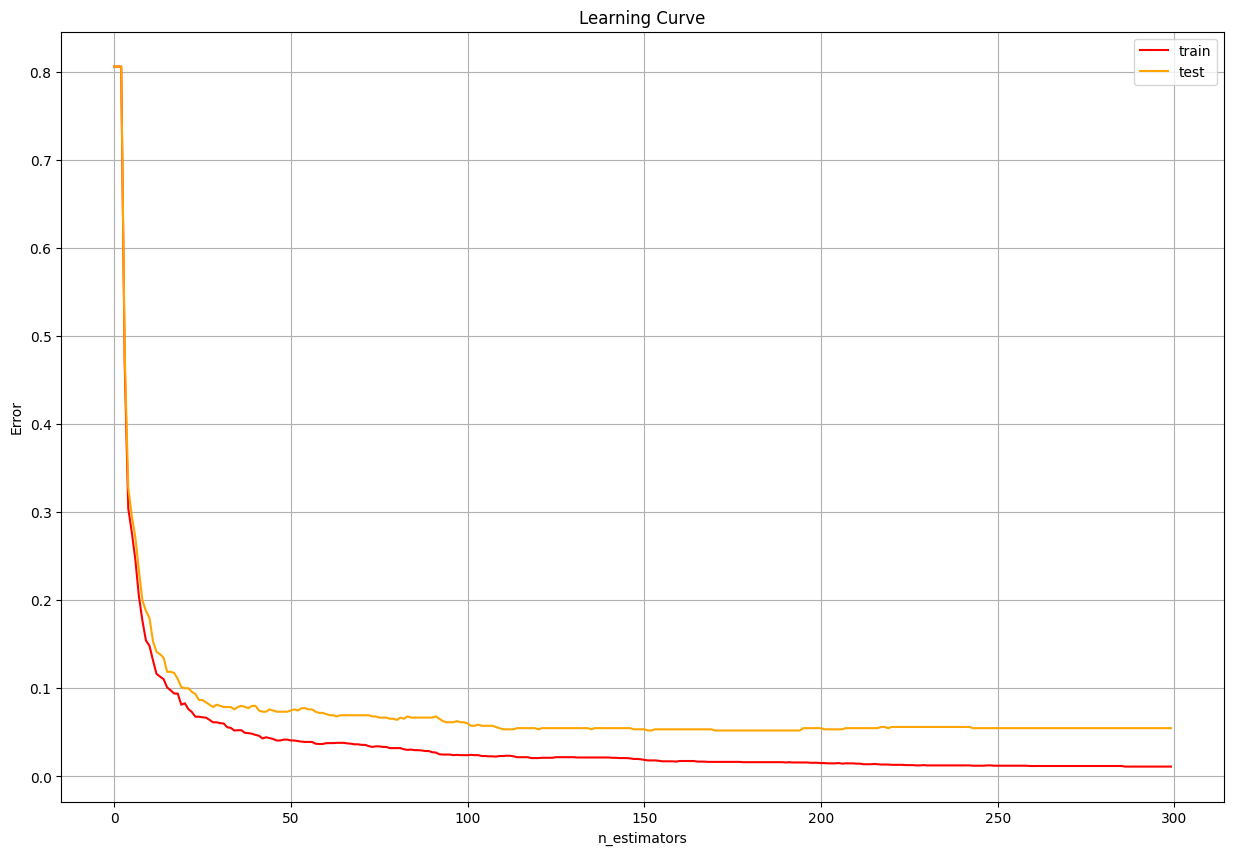

In [68]:
dtrain=xgb.DMatrix(xtrain,ytrain)
param0={'silent':True
        ,'obj':'binary:logistic'
        ,'eval_metric': 'error'
        ,'subsample':1
        ,'max_depth':4
        ,'eta':0.05
        ,'gamma':0
        ,'lambda':0
        ,'alpha':0
        ,'colsample_bytree':1
        ,'colsample_bylevel':1
        ,'colsample_bynode':1
        ,'scale_pos_weight':6
        ,'random_state':0}
n_estimators=300
curve0=xgb.cv(param0,dtrain,n_estimators,5)
fig,ax=plt.subplots(1,figsize=(15,10))
ax.grid()
ax.plot(range(num_round),curve0.iloc[:,0],c="red",label="train")
ax.plot(range(num_round),curve0.iloc[:,2],c="orange",label="test")
ax.legend()
plt.xlabel('n_estimators')
plt.ylabel('Error')
plt.title('Learning Curve')
plt.show()

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:20:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


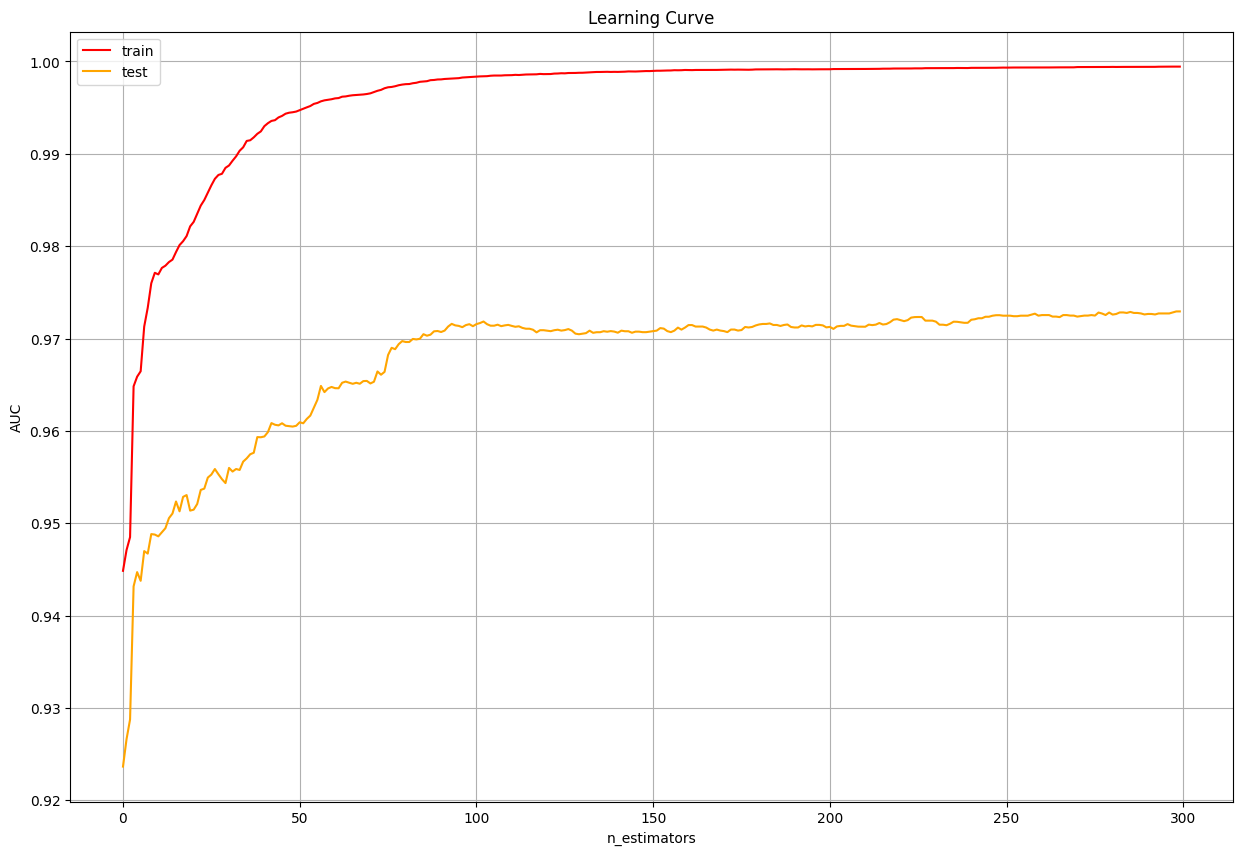

In [70]:
dtrain=xgb.DMatrix(xtrain,ytrain)
param0={'silent':True
        ,'obj':'binary:logistic'
        ,'eval_metric': 'auc'
        ,'subsample':1
        ,'max_depth':4
        ,'eta':0.05
        ,'gamma':0
        ,'lambda':0
        ,'alpha':0
        ,'colsample_bytree':1
        ,'colsample_bylevel':1
        ,'colsample_bynode':1
        ,'scale_pos_weight':6
        ,'random_state':0}
n_estimators=300
curve0=xgb.cv(param0,dtrain,n_estimators,5)
fig,ax=plt.subplots(1,figsize=(15,10))
ax.grid()
ax.plot(range(num_round),curve0.iloc[:,0],c="red",label="train")
ax.plot(range(num_round),curve0.iloc[:,2],c="orange",label="test")
ax.legend()
plt.xlabel('n_estimators')
plt.ylabel('AUC')
plt.title('Learning Curve')
plt.show()

In [23]:
dtrain=xgb.DMatrix(x_standard1,data_train0.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':6
            ,'random_state':0}
n_estimators=200
model_d=xgb.train(param0,dtrain,n_estimators)
# pickle.dump(model_d, open("XGBoost_d.dat","wb"))

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:22:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


<Figure size 700x600 with 0 Axes>

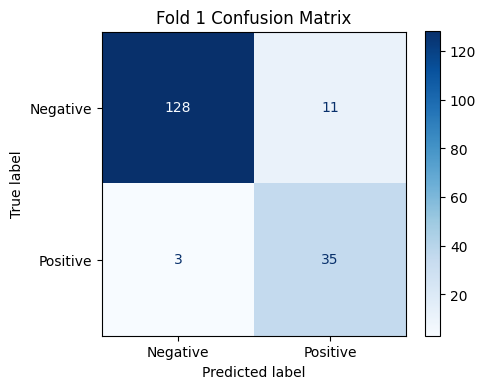

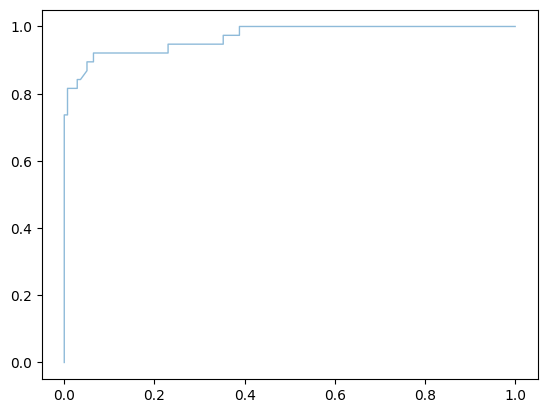

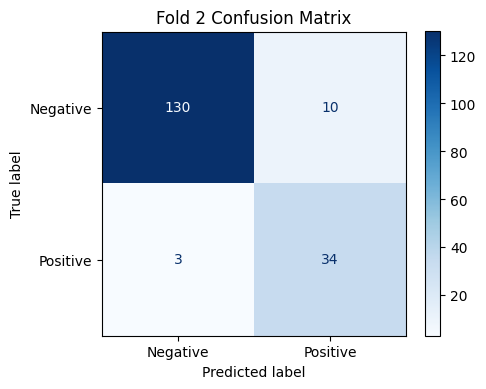

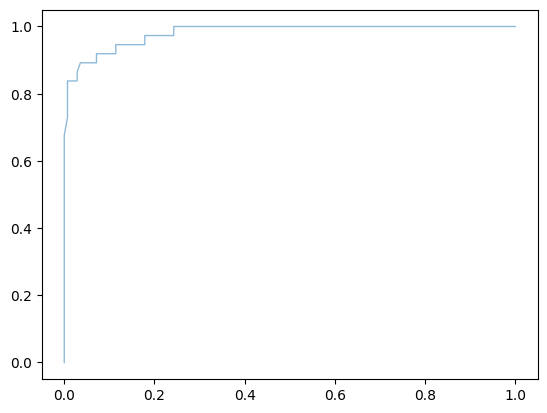

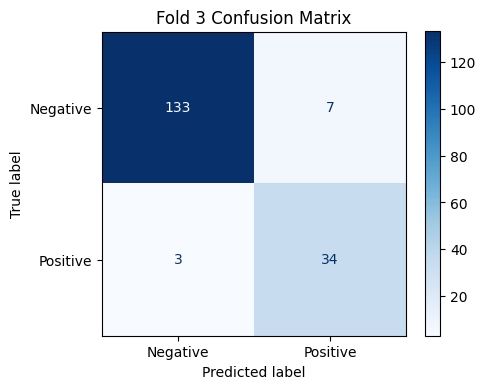

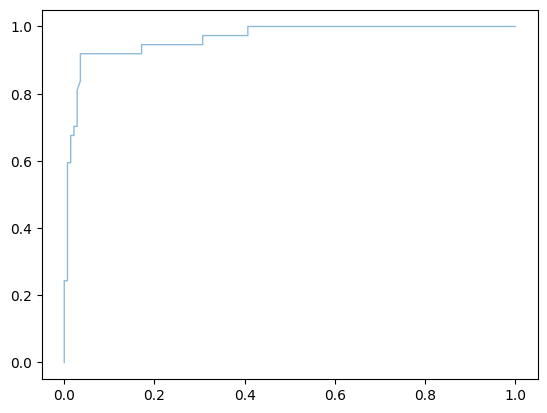

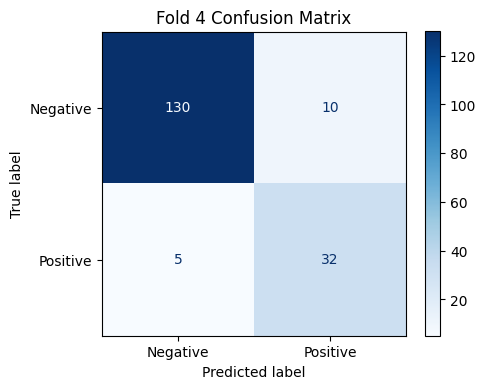

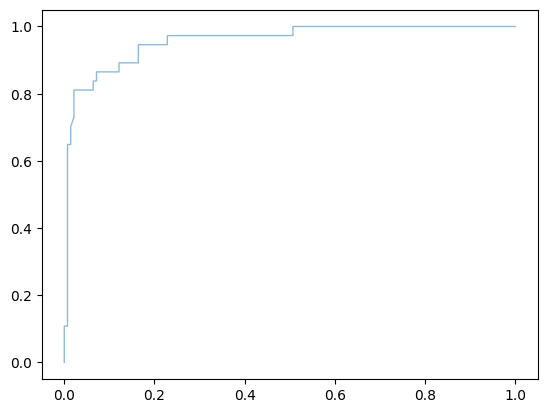

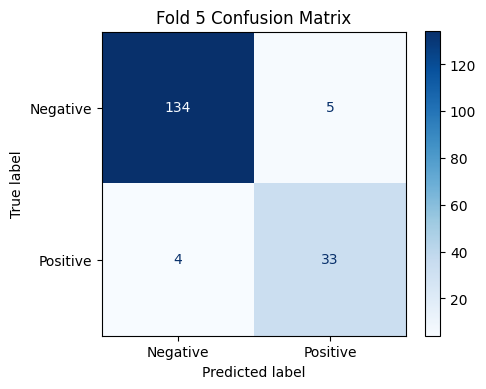

AUC       : 0.9719 ± 0.0108
Accuracy  : 0.9310 ± 0.0130
Already Saved


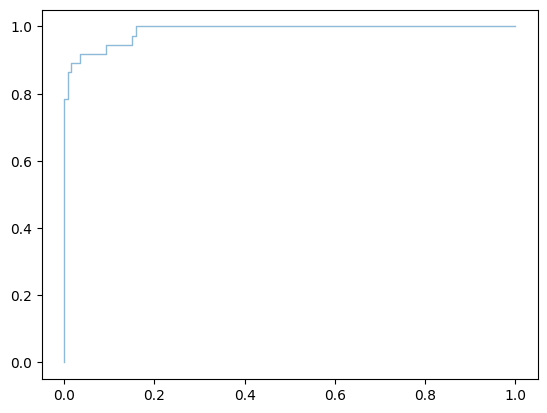

In [9]:
#-------------5 folds experiments-----------------------
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

x_5folds = data_train0.iloc[:,2:-1]
y_5folds = data_train0.iloc[:,-1]

# 标准化
scaler_5folds = StandardScaler()
x_standard_5folds = scaler_5folds.fit_transform(x_5folds)

auc_list = []
acc_list = []
roc_data = {}

mean_fpr = np.linspace(0,1,1000)
tprs = []

plt.figure(figsize=(7,6))

for fold, (train_idx, test_idx) in enumerate(skf.split(x_standard_5folds, y_5folds)):

    X_train, X_test = x_standard_5folds[train_idx], x_standard_5folds[test_idx]
    y_train, y_test = y_5folds.iloc[train_idx], y_5folds.iloc[test_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    param = {
        'objective':'binary:logistic',
        'eval_metric':'auc',
        'subsample':1,
        'max_depth':4,
        'eta':0.05,
        'gamma':0,
        'lambda':0,
        'alpha':0,
        'colsample_bytree':1,
        'scale_pos_weight':6,
        'random_state':0
    }

    model = xgb.train(
        param,
        dtrain,
        200
    )

    y_prob = model.predict(dtest)
    y_pred = (y_prob > 0.55).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
   
    disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'])
    
    disp.plot(
    cmap='Blues',
    ax=ax_cm,
    values_format='d'
    )
    ax_cm.set_title(f'Fold {fold+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    auc_list.append(roc_auc)
    acc_list.append(acc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(
        fpr,
        tpr,
        lw=1,
        alpha=0.5,
        label=f'Fold {fold+1} AUC={roc_auc:.3f}'
    )
    
    roc_data[f'Fold_{fold+1}'] = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr 
})
print(f"AUC       : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
print(f"Accuracy  : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")

output_file = 'Descritor_5fold_ROC_data.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for sheet_name, df in roc_data.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)
print("Already Saved")

<Figure size 700x600 with 0 Axes>

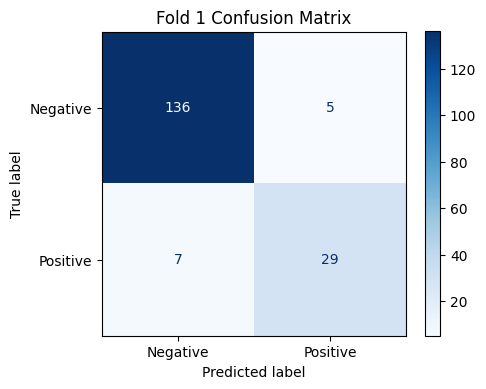

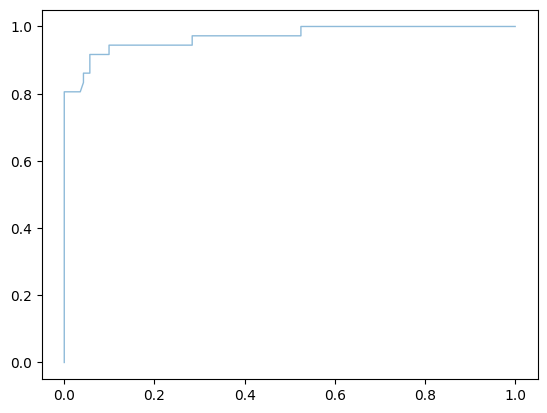

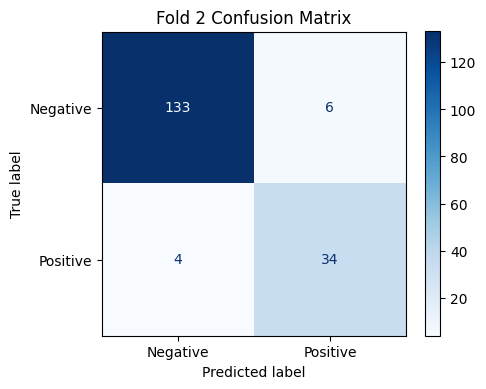

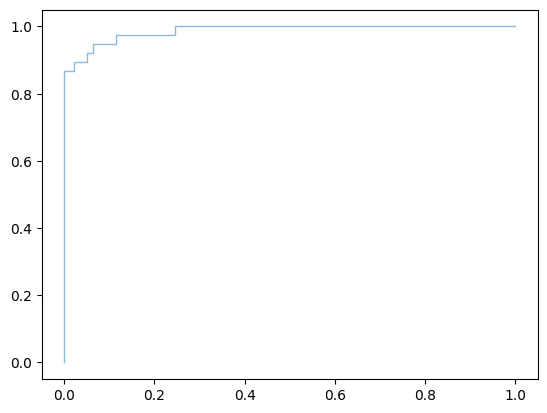

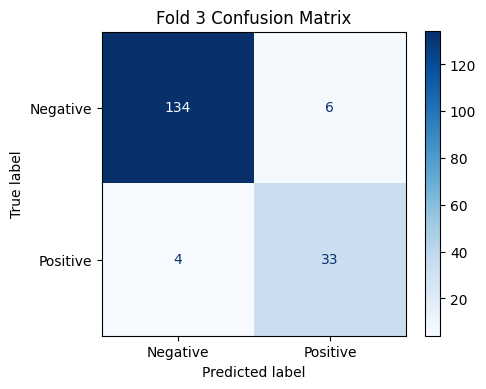

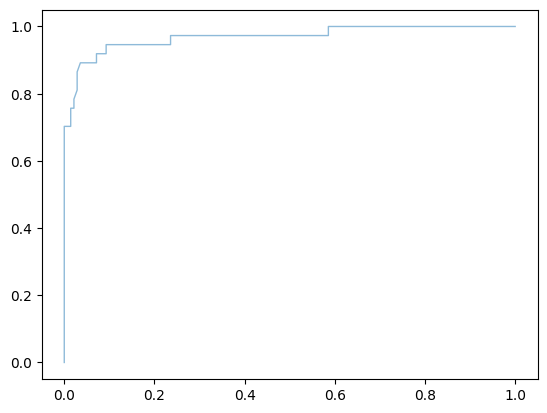

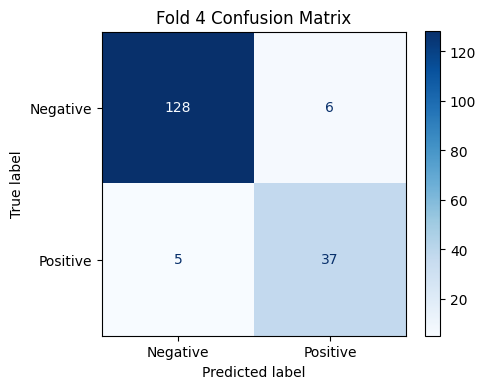

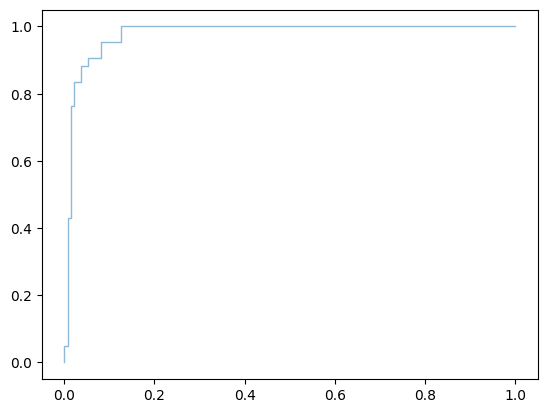

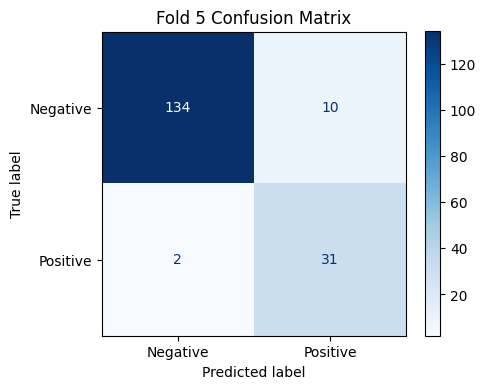

ROC-AUC           : 0.9768 ± 0.0069
Accuracy          : 0.9378 ± 0.0051
Already Saved


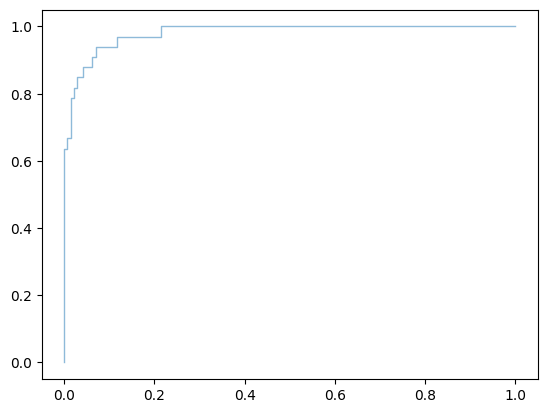

In [11]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

x_group_5folds = data_train0.iloc[:,2:-1]
y_group_5folds = data_train0.iloc[:,-1]

groups = data_train0.iloc[:,0]

scaler = StandardScaler()
x_standard_group_5folds = scaler.fit_transform(x_group_5folds)

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

auc_list2 = []
acc_list2 = []
roc_data2 = {}

mean_fpr = np.linspace(0,1,1000)
tprs = []

plt.figure(figsize=(7,6))

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(x_standard_group_5folds, y_group_5folds, groups)
):

    X_train = x_standard_group_5folds[train_idx]
    X_test = x_standard_group_5folds[test_idx]

    y_train = y_group_5folds.iloc[train_idx]
    y_test = y_group_5folds.iloc[test_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    param = {
        'objective':'binary:logistic',
        'eval_metric':'auc',
        'max_depth':4,
        'eta':0.05,
        'subsample':1,
        'colsample_bytree':1,
        'gamma':0,
        'lambda':0,
        'alpha':0,
        'scale_pos_weight':6,
        'random_state':0
    }

    model = xgb.train(
        param,
        dtrain,
        num_boost_round=200
    )

    y_prob = model.predict(dtest)
    y_pred = (y_prob > 0.55).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
   
    disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'])
    
    disp.plot(
    cmap='Blues',
    ax=ax_cm,
    values_format='d'
    )
    ax_cm.set_title(f'Fold {fold+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    acc = accuracy_score(y_test, y_pred)
    acc_list2.append(acc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_list2.append(roc_auc)

    interp_tpr = np.interp(
        mean_fpr,
        fpr,
        tpr
    )

    interp_tpr[0] = 0.0

    tprs.append(interp_tpr)

    plt.plot(
        fpr,
        tpr,
        lw=1,
        alpha=0.5,
        label=f'Fold {fold+1} AUC={roc_auc:.3f}'
    )
    roc_data2[f'Fold_{fold+1}'] = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr })

mean_tpr = np.mean(tprs, axis=0)

mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

std_auc = np.std(auc_list2)

print(f"ROC-AUC           : {np.mean(auc_list2):.4f} ± {np.std(auc_list2):.4f}")
print(f"Accuracy          : {np.mean(acc_list2):.4f} ± {np.std(acc_list2):.4f}")

output_file2 = 'Descriptor_group_5fold_ROC_data.xlsx'

with pd.ExcelWriter(output_file2, engine='openpyxl') as writer:
    for sheet_name, df in roc_data2.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)
print("Already Saved")

In [25]:
dtest = xgb.DMatrix(x_standard1)
pred=model_d.predict(dtest)
pre = pd.DataFrame(pred)

when tpr-fpr is max, the threshold is 0.57568747
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.00143266 0.00143266 0.00143266
 0.00143266 0.00573066 0.00573066 0.00573066 0.00573066 0.00716332
 0.00716332 0.01146132 0.01289398 0.01289398 0.01575931 0.01862464
 0.02148997 0.0243553  0.03008596 0.03295129 0.03724928 0.04154728
 0.04441261 0.04727794 0.0530086  0.05587393 0.05730659 0.06303725
 0.06733524 0.07020057 0.07449857 0.0773639  0.08166189 0.08739255
 0.10601719 0.11031519 0.11174785 0.11747851 0.13037249 0.13323782
 0.14326648 0.14756447 0.16762178 0.17048711 0.18338109 0.18624642
 0.19340974 0.20057307 0.20630372 0.20916905 0.22636103 0.22922636
 0.23065903 0.23352436 0.24068768 0.24641834 0.24928367 0.25501433
 0.26361032 0.26790831 0.29083095 0.29512894 

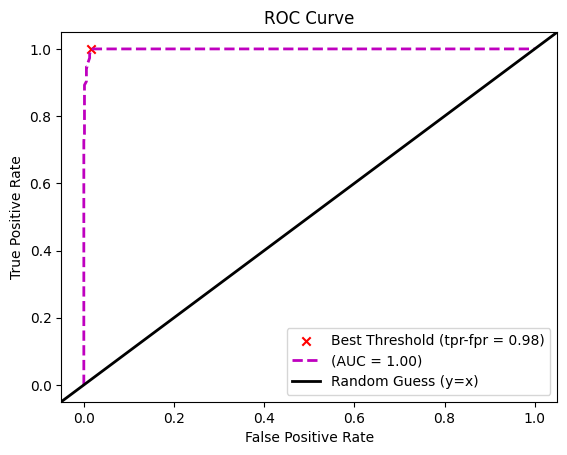

In [113]:
graph.ROC_curve(data_train0.iloc[:,-1],pred,1,True,"\\roc_descriptor_d.xlsx")

Best Threshold:  0.57568747
Best F1-score:  0.9712793733681463
[1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.     

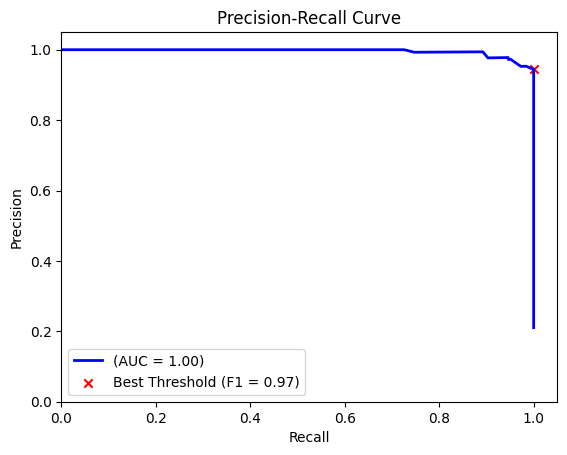

In [115]:
graph.PR_curve(data_train0.iloc[:,-1],pred,1,True,"\\pr_descriptor_d.xlsx")

In [29]:
ypred = pred.copy()
ypred[pred >0.55]=1
ypred[ypred!=1]=0

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

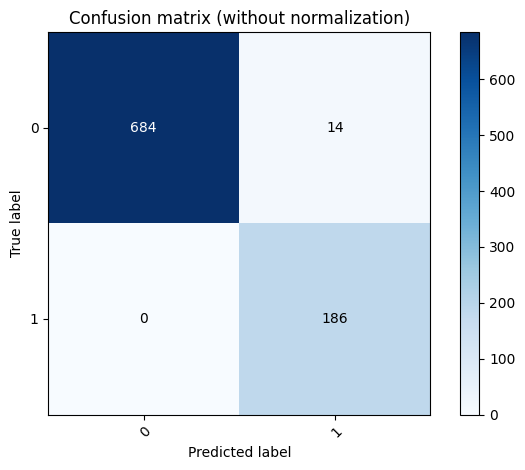

In [31]:
graph.plot_confusion_matrix(data_train0.iloc[:,-1],ypred,np.array(["0","1"]))

In [43]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, precision_recall_curve, roc_curve, auc

y_true = data_train0.iloc[:, -1]

y_pred = (pred > 0.55).astype(int)

y_pred = np.array(y_pred).flatten()

mcc = matthews_corrcoef(y_true, y_pred)

bacc = balanced_accuracy_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)
pr_auc = auc(recall, precision)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print(f"MCC: {mcc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

MCC: 0.9546
Balanced Accuracy: 0.9900
PR-AUC: 0.9650
ROC-AUC: 0.9900


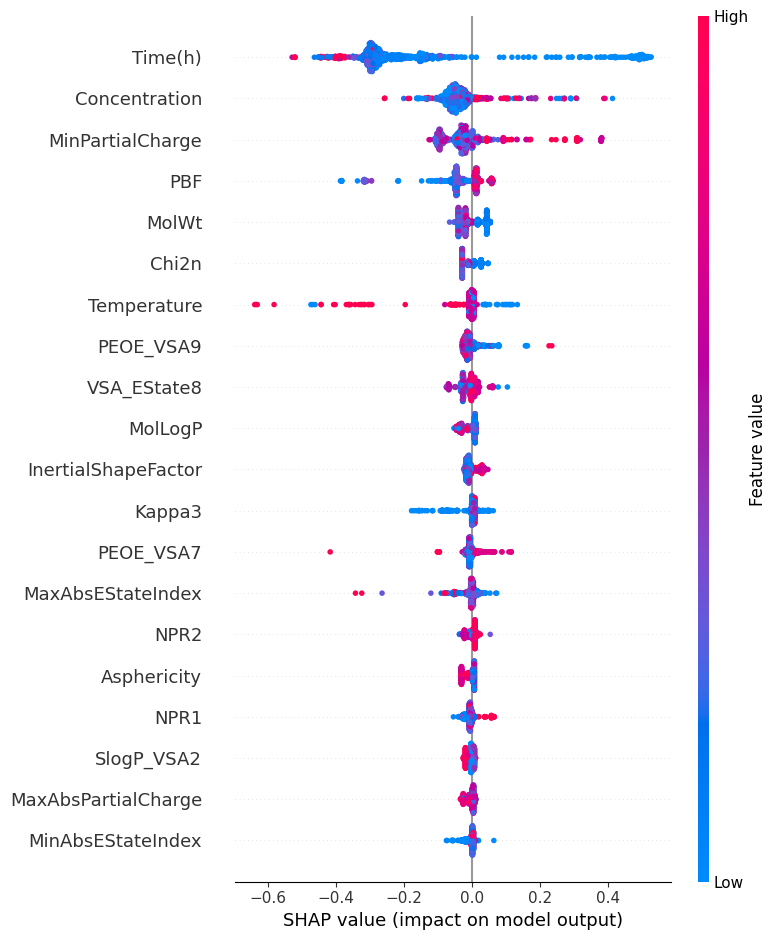

In [122]:
import shap

explainer = shap.TreeExplainer(model_d)
shap_values = explainer.shap_values(x_standard1)
plt.figure()
shap.summary_plot(shap_values,x_standard1)
# plt.savefig(r'C:\Users\hp\Desktop\AEM_project\output_graph\xgb_d_shap.png', format='png',dpi = 1000)

In [124]:
df_all = []
for i in range(x_standard1.shape[1]):
    df_i = pd.DataFrame({
        "SHAP Value": shap_values[:, i],
        "Feature Value": x_standard1.iloc[:, i],
        "Feature Name": [f"Feature_{i}"] * x_standard1.shape[0]
    })
    df_all.append(df_i)

df_total = pd.concat(df_all, ignore_index=True)
# df_total.to_excel("shap_all_features_d.xlsx", index=False)

In [139]:
dtest = xgb.DMatrix(y_standard)
y_pred = model_d.predict(dtest)
y_pred = pd.DataFrame(y_pred)
y_pred.columns = ['level']

ypred0 = y_pred.copy()
ypred0[y_pred >0.55]=1
ypred0[ypred0!=1]=0
ypred1 = pd.DataFrame(ypred0)
ypred1.columns = ['predict_class']

output = pd.concat([data_test0.iloc[:,:2],ypred1, y_pred], axis=1)
output.to_excel('output_d_all.xlsx', index=False)

In [150]:
k = []
for i in range(len(output.index)):
    if output.iloc[i,2]==1:
        k.append(i)
output0 = output.iloc[k,:]
output0.reset_index(inplace=True, drop=True)

In [154]:
from rdkit import rdBase
rdBase.DisableLog('rdApp.warning')
from rdkit import Chem
from rdkit.Contrib.SA_Score import sascorer
SMILES=output0['smiles']
SA=[]
for n,i in enumerate(SMILES):
       x_mol=Chem.MolFromSmiles(i)  
       SAscore=sascorer.calculateScore(x_mol)
       SA.append(SAscore)

output_final=pd.concat([output0,pd.DataFrame(SA,columns=['SA'])],axis=1)

num = len(output0.index)

ll = []
for ii in range(num):
    i = output0.iloc[ii,1]
    if '#'  in i or 'Si' in i or 'Br'  in i or 'Cl' in i or 'I'  in i or 'C(=O)O' in i or 'B' in i:
        ll.append(ii)
output_final.drop(index=ll, inplace=True, axis=0)
output_final.reset_index(inplace=True, drop=True)

print(output_final)
output_final.to_excel('output_d.xlsx', index=False)

        num                                             smiles  predict_class  \
0       208  C[Sn](C)(C)c1ccc(O[C@H]2C[N@+]3(C)CC[C@H]2CC3)cc1            1.0   
1        18                                CCC[C@H]1CCCC[N+]1C            1.0   
2        60                             C[N+]1C(C)(C)CCCC1(C)C            1.0   
3       130  C[N+]1CCCC[C@@H]1[C@]12C[C@H]3C[C@H](C[C@H](C3...            1.0   
4       145  C[N+]1CCCC[C@]12[C@@H]1C[C@H]3C[C@@H](C1)C[C@@...            1.0   
...     ...                                                ...            ...   
5270  68715         Cc1cc(C)c(-[n+]2cc(-c3ccccc3)n(C)n2)c(C)c1            1.0   
5271  69098    Cc1ccccc1-[n+]1cc2ccccc2c(-c2ccccc2)c1-c1ccccc1            1.0   
5272  69258  C1=C/CCCC[n+]2cccc(c2)CCCCCCCCCCCC[n+]2cccc(c2...            1.0   
5273  69344   CCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccc(C(C)(C)C)cc1            1.0   
5274  69381  CCN(CC)p1n(-c2c(C)cc(C)cc2C)c[n+]1-c1c(C)cc(C)...            1.0   

         level        SA  


In [59]:
d_p = pd.read_excel("output14.xlsx")
l_p = d_p['smiles_d'].tolist()
print(l_p)

m = 0
for i in l_p:
    to_p = smg.GetDescriptors(i, 1, 80, 720)  
    to_p_standard = pd.DataFrame(scaler1.transform(to_p))
    to_p_standard.columns = to_p.columns

    # 计算 SHAP 值
    explainer = shap.TreeExplainer(model_d)
    shap_values = explainer.shap_values(to_p_standard)

    # **四舍五入处理 SHAP 值和输入特征**
    shap_values_rounded = np.round(shap_values, 2) 
    to_p_standard_rounded = to_p_standard.round(2) 

    # 生成 force_plot
    fig = shap.force_plot(
        explainer.expected_value, 
        shap_values_rounded, 
        to_p_standard_rounded, 
        show=False, 
        matplotlib=True
    )

    # **调整坐标刻度格式**
    plt.gca().set_xticklabels([f"{tick:.2f}" for tick in plt.gca().get_xticks()])
    plt.gca().set_yticklabels([f"{tick:.2f}" for tick in plt.gca().get_yticks()])

    # 保存图片
    plt.savefig(r'C:\Users\hp\Desktop\shap\d_' + str(m) + '.png', format='png', dpi=1000)
    plt.close()  
    m += 1

['C1CCN(O[P+](N2CCCCC2)(N2CCCCC2)N2CCCCC2)CC1', 'C1CCN([P+](N2CCCCC2)(N2CCCCC2)N2CCCCC2)CC1', 'C[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1', 'CC(C)(C)[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1', 'CN(C)[P+](ON1CCCCC1)(N(C)C)N(C)C', 'CN[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1', 'CC[N+](N1CCCCC1)(N1CCCCC1)N1CCCCC1', 'CN(C)[P+](N(C)C)(N(C)C)N1CCCCC1', 'CC(C)N(CCn1cc[n+](CCN(C(C)C)C(C)C)c1)C(C)C', 'CCCCc1nn(CC)n[n+]1CCCC', 'CCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccccc1', 'CCCCCCCCCCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccc(C(C)(C)C)cc1', 'CCCCCC[N+]1=NN=NC1(c1ccccc1)c1ccccc1', 'CCCCCCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccc(C(C)(C)C)cc1', 'C1CC[N+]2(CC1)CCCCC2', 'CCCCCCCCCCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccccc1', 'CCCCCCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccc(C(C)(C)C)cc1', 'CCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccc(C(C)(C)C)cc1', 'CCCCCCCCCCCCCP=[N+]=PCCCCCCCCCCCCC', 'Cc1n(CCN(C)C)cc[n+]1CCN(C)C', 'CCCC[n+]1ccn([C@H](N)CC)c1', 'CCCCCCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccccc1', 'CCCP(CCC)(CCC)=[N+]=P(CCC)(CCC)CCC', 'CCCCCCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccccc1', 'C

[18:17:24] UFFTYPER: Unrecognized charge state for atom: 5
C:\Users\hp\AppData\Local\Temp\ipykernel_19604\852546181.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{tick:.2f}" for tick in plt.gca().get_xticks()])
C:\Users\hp\AppData\Local\Temp\ipykernel_19604\852546181.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{tick:.2f}" for tick in plt.gca().get_yticks()])
[18:17:33] UFFTYPER: Unrecognized charge state for atom: 4
C:\Users\hp\AppData\Local\Temp\ipykernel_19604\852546181.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{tick:.2f}" for tick in plt.gca().get_xticks()])
C:\Users\hp\AppData\Local\Temp\ipykernel_19604\852546181.py:36: Us